##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

Loaded 20 images (10 cats, 10 dogs)


Feature matrix shape: (20, 384)



Cluster accuracy vs ground truth: 100.0%
Confusion matrix (rows = truth [cat, dog], cols = predicted cluster):
[[10  0]
 [ 0 10]]


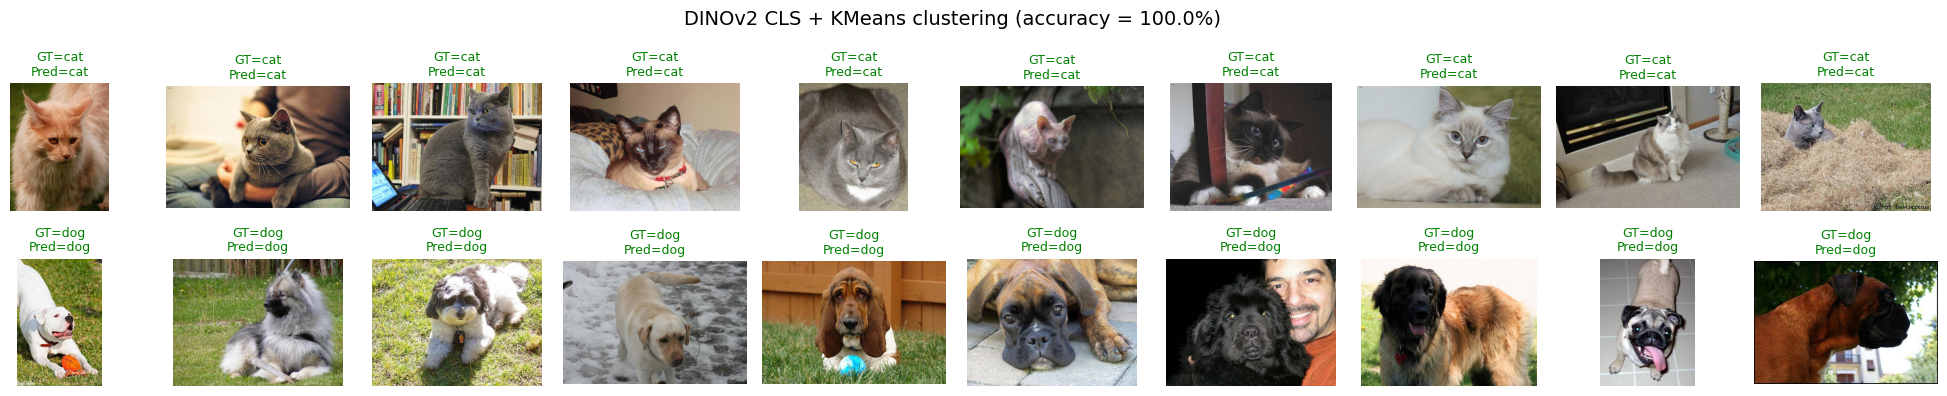

In [1]:
# --- Exercise 1: Unsupervised clustering of pet images with DINOv2 + KMeans ---
import os, certifi
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix

MODEL_ID = "facebook/dinov2-small"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Step 1 - Load 20 Oxford-IIIT Pet images (10 cats, 10 dogs) from the local
# `data/pets/` folder.  The images were sampled once from the HF mirror
# `timm/oxford-iiit-pet` using the `label_cat_dog` field (0 = cat, 1 = dog)
# and committed alongside the notebook so the exercise is reproducible without
# re-streaming the dataset every run.
PETS_DIR = Path("data/pets")
cat_paths = sorted(PETS_DIR.glob("cat_*.jpg"))[:10]
dog_paths = sorted(PETS_DIR.glob("dog_*.jpg"))[:10]
assert len(cat_paths) == 10 and len(dog_paths) == 10, (
    f"Need 10 cats and 10 dogs in {PETS_DIR}; got {len(cat_paths)} cats, {len(dog_paths)} dogs"
)

images = [Image.open(p).convert("RGB") for p in cat_paths + dog_paths]
labels = np.array([0] * 10 + [1] * 10)  # 0 = cat, 1 = dog (ground truth)
print(f"Loaded {len(images)} images ({(labels == 0).sum()} cats, {(labels == 1).sum()} dogs)")

# Step 2 - Extract the 384-d CLS tokens with DINOv2-small
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device).eval()

@torch.no_grad()
def cls_token(img):
    inputs = processor(images=img, return_tensors="pt").to(device)
    out = model(**inputs)
    feat = F.normalize(out.last_hidden_state[:, 0], p=2, dim=1)
    return feat.cpu().numpy()[0]

features = np.stack([cls_token(img) for img in images])
print("Feature matrix shape:", features.shape)   # (20, 384)

# Step 3 - K-Means (n=2) on the CLS tokens
km = KMeans(n_clusters=2, random_state=0, n_init=10).fit(features)
pred = km.labels_

# K-Means cluster ids are arbitrary - align with ground truth by majority vote
aligned = pred if accuracy_score(labels, pred) >= accuracy_score(labels, 1 - pred) else 1 - pred
acc = accuracy_score(labels, aligned)
cm = confusion_matrix(labels, aligned)
print(f"\nCluster accuracy vs ground truth: {acc * 100:.1f}%")
print("Confusion matrix (rows = truth [cat, dog], cols = predicted cluster):")
print(cm)

# Visualise the two clusters
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for ax, img, gt, pr in zip(axes.flat, images, labels, aligned):
    ax.imshow(img)
    ax.set_title(f"GT={'cat' if gt == 0 else 'dog'}\nPred={'cat' if pr == 0 else 'dog'}",
                 color=("green" if gt == pr else "red"), fontsize=9)
    ax.axis("off")
plt.suptitle(f"DINOv2 CLS + KMeans clustering (accuracy = {acc * 100:.1f}%)", fontsize=14)
plt.tight_layout()
plt.show()


### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Image: data\golden_retriever.jpg size: (960, 640)



Top-5 ImageNet-1k predictions:
  golden retriever                               p=0.9091
  Labrador retriever                             p=0.0278
  clumber, clumber spaniel                       p=0.0207
  English setter                                 p=0.0133
  Sussex spaniel                                 p=0.0047


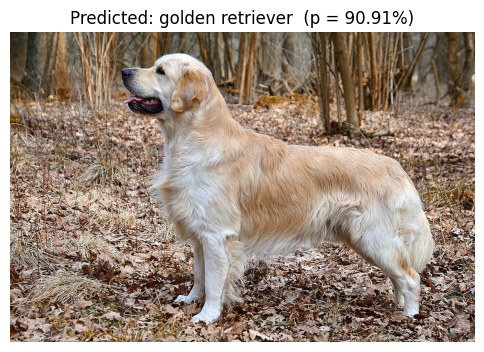

In [2]:
# --- Exercise 2: Image classification with DINOv2 + ImageNet-1k linear head ---
import os, io, certifi
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

from pathlib import Path
import requests
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

CLF_MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Step 1 - Download an image of a Golden Retriever (an ImageNet-1k class).
# We resolve the real Wikimedia URL via the Commons API, then cache the image
# under data/golden_retriever.jpg so re-runs do not hit the network.
img_path = Path("data/golden_retriever.jpg")
if not img_path.exists():
    api = "https://commons.wikimedia.org/w/api.php"
    ua = {"User-Agent": "arti560-lab10 (educational)"}
    resp = requests.get(api, params={
        "action": "query",
        "titles": "File:Golden Retriever Carlos (10581910556).jpg",
        "prop": "imageinfo", "iiprop": "url", "iiurlwidth": 640, "format": "json",
    }, headers=ua, timeout=30, verify=certifi.where()).json()
    img_url = next(iter(resp["query"]["pages"].values()))["imageinfo"][0]["thumburl"].split("?", 1)[0]
    img_path.parent.mkdir(parents=True, exist_ok=True)
    img_path.write_bytes(requests.get(img_url, headers=ua, timeout=30, verify=certifi.where()).content)

img = Image.open(img_path).convert("RGB")
print("Image:", img_path, "size:", img.size)

# Step 2 - Load the DINOv2-small backbone with the 1-layer ImageNet-1k head
processor = AutoImageProcessor.from_pretrained(CLF_MODEL_ID)
model = AutoModelForImageClassification.from_pretrained(CLF_MODEL_ID).to(device).eval()

# Step 3 - Forward pass and decode the top-5 predictions
inputs = processor(images=img, return_tensors="pt").to(device)
with torch.no_grad():
    logits = model(**inputs).logits

probs = torch.softmax(logits, dim=-1)[0]
top5 = torch.topk(probs, k=5)
id2label = model.config.id2label

print("\nTop-5 ImageNet-1k predictions:")
for prob, idx in zip(top5.values.tolist(), top5.indices.tolist()):
    print(f"  {id2label[idx]:45s}  p={prob:.4f}")

# Show the image with the top-1 label
top1_label = id2label[top5.indices[0].item()]
top1_prob = top5.values[0].item()
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Predicted: {top1_label}  (p = {top1_prob:.2%})")
plt.axis("off")
plt.show()
